# Multi-Asset 5-Day Direction Forecasting

This version uses the full dataset, but the target is stronger than the earlier next-day setup.

Instead of asking the model to guess tomorrow's tiny move, it predicts whether the asset is higher after the next 5 trading days.

Target:

- `1` = price is higher after 5 trading days
- `0` = price is flat or lower after 5 trading days

This is still a real forecasting task, but it gives the models a better chance because one-day returns are mostly noise.

## 1. Imports

In [5]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 2. Load data

This reads the selected ETFs and stocks from the Kaggle stock market dataset.

Change `BASE_PATH` only if your folder is different.

In [6]:
kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

Using Colab cache for faster access to the 'stock-market-dataset' dataset.


'/kaggle/input/stock-market-dataset'

In [7]:
# Kaggle path
BASE_PATH = "/kaggle/input/stock-market-dataset"

etf_tickers = [
    "GLD", "SLV", "GDX", "GDXJ",
    "SPY", "QQQ", "DIA", "IWM",
    "UUP", "TLT", "TIP",
    "USO", "DBC",
    "UVXY", "VIXY",
    "XLF", "EEM"
]

stock_tickers = [
    "GOLD", "NEM", "AEM", "FNV", "KGC",
    "AAPL", "MSFT", "NVDA", "TSLA"
]
meta_path = os.path.join(BASE_PATH, "symbols_valid_meta.csv")
if os.path.exists(meta_path):
    meta_df = pd.read_csv(meta_path)[["Symbol", "Security Name", "ETF"]]
else:
    meta_df = pd.DataFrame(columns=["Symbol", "Security Name", "ETF"])
dfs = []
missing_files = []

for ticker in etf_tickers:
    file_path = os.path.join(BASE_PATH, "etfs", f"{ticker}.csv")
    if os.path.exists(file_path):
        temp = pd.read_csv(file_path)
        temp["Ticker"] = ticker
        temp["Asset_Type"] = "ETF"
        dfs.append(temp)
    else:
        missing_files.append(file_path)

for ticker in stock_tickers:
    file_path = os.path.join(BASE_PATH, "stocks", f"{ticker}.csv")
    if os.path.exists(file_path):
        temp = pd.read_csv(file_path)
        temp["Ticker"] = ticker
        temp["Asset_Type"] = "Stock"
        dfs.append(temp)
    else:
        missing_files.append(file_path)

# if len(dfs) == 0:
#     raise FileNotFoundError("No ticker files found. Check BASE_PATH.")

raw_df = pd.concat(dfs, ignore_index=True)

raw_df = raw_df.merge(
    meta_df,
    left_on="Ticker",
    right_on="Symbol",
    how="left"
)

print("Loaded shape:", raw_df.shape)
print("Tickers loaded:", raw_df["Ticker"].nunique())
print("Missing files:", len(missing_files))
raw_df.head()

Loaded shape: (139303, 12)
Tickers loaded: 26
Missing files: 0


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Asset_Type,Symbol,Security Name,ETF
0,2004-11-18,44.430000,44.490002,44.070000,44.380001,44.380001,5992000.0,GLD,ETF,GLD,SPDR Gold Trust,Y
1,2004-11-19,44.490002,44.919998,44.470001,44.779999,44.779999,11655300.0,GLD,ETF,GLD,SPDR Gold Trust,Y
2,2004-11-22,44.750000,44.970001,44.740002,44.950001,44.950001,11996000.0,GLD,ETF,GLD,SPDR Gold Trust,Y
3,2004-11-23,44.880001,44.919998,44.720001,44.750000,44.750000,3169200.0,GLD,ETF,GLD,SPDR Gold Trust,Y
4,2004-11-24,44.930000,45.049999,44.790001,45.049999,45.049999,6105100.0,GLD,ETF,GLD,SPDR Gold Trust,Y


## 3. Data cleaning

The loading code above is unchanged.

From here, the notebook cleans the data and keeps the full multi-asset table.

In [8]:
df = raw_df.copy()

df["Date"] = pd.to_datetime(df["Date"])

required_cols = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume", "Ticker", "Asset_Type"]
df = df[required_cols + [c for c in ["Symbol", "Security Name", "ETF"] if c in df.columns]]

df = df.drop_duplicates(subset=["Ticker", "Date"])
df = df.dropna(subset=["Date", "Open", "High", "Low", "Close", "Volume", "Ticker"])

df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Tickers:", df["Ticker"].nunique())
display(df["Ticker"].value_counts().sort_index())

Cleaned shape: (139299, 12)
Date range: 1973-02-21 00:00:00 to 2020-04-01 00:00:00
Tickers: 26


,count
Ticker,
AAPL,9909
AEM,11884
DBC,3563
DIA,5587
EEM,4272
FNV,3100
GDX,3490
GDXJ,2614
GLD,3868


## 4. Feature engineering per ticker

Everything here is built inside each ticker.

That is the non-negotiable part. If features roll from one ticker into another, the notebook becomes useless.

In [9]:
FORECAST_HORIZON = 5


def add_ticker_features(group):
    group = group.sort_values("Date").copy()

    # Basic daily movement
    group["Daily_Return"] = group["Close"].pct_change()
    group["Log_Return"] = np.log(group["Close"] / group["Close"].shift(1))
    group["High_Low_Range_Pct"] = (group["High"] - group["Low"]) / group["Close"]
    group["Open_Close_Range_Pct"] = (group["Close"] - group["Open"]) / group["Open"]
    group["Volume_Change"] = group["Volume"].pct_change()

    # Lagged returns. These are safer than raw prices across assets.
    for lag in [1, 2, 3, 5, 10, 20]:
        group[f"Return_Lag_{lag}"] = group["Daily_Return"].shift(lag)

    # Momentum over different windows
    for window in [3, 5, 10, 20, 30, 60]:
        group[f"Momentum_{window}"] = group["Close"] / group["Close"].shift(window) - 1

    # Rolling volatility. Volatility clustering is usually more predictable than raw returns.
    for window in [5, 10, 20, 30, 60]:
        group[f"Volatility_{window}"] = group["Daily_Return"].rolling(window).std()

    # Moving-average distance, not raw moving average values.
    for window in [5, 10, 20, 50, 100]:
        ma = group["Close"].rolling(window).mean()
        group[f"MA_Distance_{window}"] = group["Close"] / ma - 1

    # Volume pressure
    vol_mean_20 = group["Volume"].rolling(20).mean()
    vol_std_20 = group["Volume"].rolling(20).std()
    group["Volume_Z_20"] = (group["Volume"] - vol_mean_20) / vol_std_20
    group["Volume_Ratio_20"] = group["Volume"] / vol_mean_20

    # RSI
    delta = group["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    group["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD style features
    ema_12 = group["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = group["Close"].ewm(span=26, adjust=False).mean()
    group["MACD"] = ema_12 - ema_26
    group["MACD_Signal"] = group["MACD"].ewm(span=9, adjust=False).mean()
    group["MACD_Hist"] = group["MACD"] - group["MACD_Signal"]

    # Simple regime features. These are crude, but useful.
    group["Trend_Regime_20"] = (group["Close"] > group["Close"].rolling(20).mean()).astype(int)
    group["Trend_Regime_50"] = (group["Close"] > group["Close"].rolling(50).mean()).astype(int)
    group["High_Vol_Regime"] = (
        group["Volatility_20"] > group["Volatility_20"].rolling(120).median()
    ).astype(int)

    # Target: 5 trading days ahead.
    future_return = group["Close"].shift(-FORECAST_HORIZON) / group["Close"] - 1
    group["Target_Return_5D"] = future_return
    group["Target_Up_5D"] = (future_return > 0).astype(int)

    return group


feature_df = (
    df.groupby("Ticker", group_keys=False)
      .apply(add_ticker_features)
      .reset_index(drop=True)
)

print("Feature table shape:", feature_df.shape)
feature_df[["Date", "Ticker", "Close", "Target_Return_5D", "Target_Up_5D"]].head()

Feature table shape: (139299, 50)


,Date,Ticker,Close,Target_Return_5D,Target_Up_5D
0,1980-12-12,AAPL,0.513393,-0.017391,0
1,1980-12-15,AAPL,0.486607,0.087156,1
2,1980-12-16,AAPL,0.450893,0.222772,1
3,1980-12-17,AAPL,0.462054,0.256039,1
4,1980-12-18,AAPL,0.475446,0.333333,1


## 5. Market and cross-asset signals

The model also gets same-day market context.

These values are known at the close of the current day. The target is the direction after 5 trading days.

In [10]:
wide_close = df.pivot(index="Date", columns="Ticker", values="Close").sort_index()
wide_returns = wide_close.pct_change()

market_signal_tickers = [
    "GLD", "SLV", "GDX", "GDXJ",
    "SPY", "QQQ", "DIA", "IWM",
    "UUP", "TLT", "TIP", "USO", "DBC", "UVXY", "VIXY", "XLF", "EEM"
]

market_features = pd.DataFrame(index=wide_returns.index)

for ticker in market_signal_tickers:
    if ticker in wide_returns.columns:
        market_features[f"MKT_{ticker}_Ret_0"] = wide_returns[ticker]
        market_features[f"MKT_{ticker}_Ret_1"] = wide_returns[ticker].shift(1)
        market_features[f"MKT_{ticker}_Mom_5"] = wide_close[ticker] / wide_close[ticker].shift(5) - 1
        market_features[f"MKT_{ticker}_Vol_10"] = wide_returns[ticker].rolling(10).std()

# A few broad market regime signals.
if "SPY" in wide_close.columns:
    spy_ret = wide_returns["SPY"]
    spy_ma_50 = wide_close["SPY"].rolling(50).mean()
    spy_ma_200 = wide_close["SPY"].rolling(200).mean()
    market_features["SPY_Above_MA50"] = (wide_close["SPY"] > spy_ma_50).astype(int)
    market_features["SPY_Above_MA200"] = (wide_close["SPY"] > spy_ma_200).astype(int)
    market_features["SPY_Vol_Regime"] = (spy_ret.rolling(20).std() > spy_ret.rolling(120).std()).astype(int)

if "QQQ" in wide_returns.columns and "SPY" in wide_returns.columns:
    market_features["QQQ_minus_SPY_5D"] = (
        wide_close["QQQ"] / wide_close["QQQ"].shift(5) - 1
    ) - (
        wide_close["SPY"] / wide_close["SPY"].shift(5) - 1
    )

if "GLD" in wide_returns.columns and "UUP" in wide_returns.columns:
    market_features["Gold_USD_Relative_5D"] = (
        wide_close["GLD"] / wide_close["GLD"].shift(5) - 1
    ) - (
        wide_close["UUP"] / wide_close["UUP"].shift(5) - 1
    )

market_features = market_features.reset_index()

model_base_df = feature_df.merge(market_features, on="Date", how="left")

print("After market feature merge:", model_base_df.shape)
model_base_df.head()

After market feature merge: (139299, 123)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Asset_Type,Symbol,Security Name,ETF,Daily_Return,Log_Return,High_Low_Range_Pct,Open_Close_Range_Pct,Volume_Change,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Return_Lag_10,Return_Lag_20,Momentum_3,Momentum_5,Momentum_10,Momentum_20,Momentum_30,Momentum_60,Volatility_5,Volatility_10,Volatility_20,Volatility_30,Volatility_60,MA_Distance_5,MA_Distance_10,MA_Distance_20,MA_Distance_50,MA_Distance_100,Volume_Z_20,Volume_Ratio_20,RSI_14,MACD,MACD_Signal,MACD_Hist,Trend_Regime_20,Trend_Regime_50,High_Vol_Regime,Target_Return_5D,Target_Up_5D,MKT_GLD_Ret_0,MKT_GLD_Ret_1,MKT_GLD_Mom_5,MKT_GLD_Vol_10,MKT_SLV_Ret_0,MKT_SLV_Ret_1,MKT_SLV_Mom_5,MKT_SLV_Vol_10,MKT_GDX_Ret_0,MKT_GDX_Ret_1,MKT_GDX_Mom_5,MKT_GDX_Vol_10,MKT_GDXJ_Ret_0,MKT_GDXJ_Ret_1,MKT_GDXJ_Mom_5,MKT_GDXJ_Vol_10,MKT_SPY_Ret_0,MKT_SPY_Ret_1,MKT_SPY_Mom_5,MKT_SPY_Vol_10,MKT_QQQ_Ret_0,MKT_QQQ_Ret_1,MKT_QQQ_Mom_5,MKT_QQQ_Vol_10,MKT_DIA_Ret_0,MKT_DIA_Ret_1,MKT_DIA_Mom_5,MKT_DIA_Vol_10,MKT_IWM_Ret_0,MKT_IWM_Ret_1,MKT_IWM_Mom_5,MKT_IWM_Vol_10,MKT_UUP_Ret_0,MKT_UUP_Ret_1,MKT_UUP_Mom_5,MKT_UUP_Vol_10,MKT_TLT_Ret_0,MKT_TLT_Ret_1,MKT_TLT_Mom_5,MKT_TLT_Vol_10,MKT_TIP_Ret_0,MKT_TIP_Ret_1,MKT_TIP_Mom_5,MKT_TIP_Vol_10,MKT_USO_Ret_0,MKT_USO_Ret_1,MKT_USO_Mom_5,MKT_USO_Vol_10,MKT_DBC_Ret_0,MKT_DBC_Ret_1,MKT_DBC_Mom_5,MKT_DBC_Vol_10,MKT_UVXY_Ret_0,MKT_UVXY_Ret_1,MKT_UVXY_Mom_5,MKT_UVXY_Vol_10,MKT_VIXY_Ret_0,MKT_VIXY_Ret_1,MKT_VIXY_Mom_5,MKT_VIXY_Vol_10,MKT_XLF_Ret_0,MKT_XLF_Ret_1,MKT_XLF_Mom_5,MKT_XLF_Vol_10,MKT_EEM_Ret_0,MKT_EEM_Ret_1,MKT_EEM_Mom_5,MKT_EEM_Vol_10,SPY_Above_MA50,SPY_Above_MA200,SPY_Vol_Regime,QQQ_minus_SPY_5D,Gold_USD_Relative_5D
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400.0,AAPL,Stock,AAPL,Apple Inc. - Common Stock,N,NaN,NaN,0.004348,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,0,0,-0.017391,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200.0,AAPL,Stock,AAPL,Apple Inc. - Common Stock,N,-0.052174,-0.053584,0.004587,-0.004566,-0.625006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002137,-0.000427,-0.001709,0,0,0,0.087156,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000.0,AAPL,Stock,AAPL,Apple Inc. - Common Stock,N,-0.073394,-0.076227,0.004950,-0.004926,-0.398879,-0.052174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.006635,-0.001669,-0.004967,0,0,0,0.222772,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400.0,AAPL,Stock,AAPL,Apple Inc. - Common Stock,N,0.024752,0.024451,0.004831,0.000000,-0.182415,-0.073394,-0.052174,NaN,NaN,NaN,NaN,-0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009194,-0.003174,-0.006020,0,0,0,0.256039,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## 6. Final modelling table

Rows with rolling-window gaps are removed.

This is expected because indicators need history before they become valid.

In [11]:
model_df = model_base_df.copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna().reset_index(drop=True)

print("Final modelling shape:", model_df.shape)
print("Tickers used:", model_df["Ticker"].nunique())
print("Target balance:")
display(model_df["Target_Up_5D"].value_counts(normalize=True).rename("proportion"))

model_df[["Date", "Ticker", "Close", "Target_Return_5D", "Target_Up_5D"]].head()

Final modelling shape: (54878, 123)
Tickers used: 26
Target balance:


,proportion
Target_Up_5D,
1,0.51917
0,0.48083


,Date,Ticker,Close,Target_Return_5D,Target_Up_5D
0,2011-10-18,AAPL,60.320000,-0.057953,0
1,2011-10-19,AAPL,56.945713,0.004967,1
2,2011-10-20,AAPL,56.472858,0.023728,1
3,2011-10-21,AAPL,56.124287,0.030748,1
4,2011-10-24,AAPL,57.967144,-0.002440,0


## 7. Feature selection

Raw price columns are removed.

The model should learn movement behaviour, not memorize that one ticker trades at a higher price than another.

In [12]:
exclude_cols = [
    "Date", "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Target_Return_5D", "Target_Up_5D",
    "Symbol", "Security Name", "ETF"
]

candidate_features = [c for c in model_df.columns if c not in exclude_cols]

X_all = pd.get_dummies(
    model_df[candidate_features],
    columns=["Ticker", "Asset_Type"],
    drop_first=False
)

y_all = model_df["Target_Up_5D"].copy()
dates_all = model_df["Date"].copy()
tickers_all = model_df["Ticker"].copy()

print("Feature matrix:", X_all.shape)
print("Target:", y_all.shape)
X_all.head()

Feature matrix: (54878, 137)
Target: (54878,)


,Daily_Return,Log_Return,High_Low_Range_Pct,Open_Close_Range_Pct,Volume_Change,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Return_Lag_10,Return_Lag_20,Momentum_3,Momentum_5,Momentum_10,Momentum_20,Momentum_30,Momentum_60,Volatility_5,Volatility_10,Volatility_20,Volatility_30,Volatility_60,MA_Distance_5,MA_Distance_10,MA_Distance_20,MA_Distance_50,MA_Distance_100,Volume_Z_20,Volume_Ratio_20,RSI_14,MACD,MACD_Signal,MACD_Hist,Trend_Regime_20,Trend_Regime_50,High_Vol_Regime,MKT_GLD_Ret_0,MKT_GLD_Ret_1,MKT_GLD_Mom_5,MKT_GLD_Vol_10,MKT_SLV_Ret_0,MKT_SLV_Ret_1,MKT_SLV_Mom_5,MKT_SLV_Vol_10,MKT_GDX_Ret_0,MKT_GDX_Ret_1,MKT_GDX_Mom_5,MKT_GDX_Vol_10,MKT_GDXJ_Ret_0,MKT_GDXJ_Ret_1,MKT_GDXJ_Mom_5,MKT_GDXJ_Vol_10,MKT_SPY_Ret_0,MKT_SPY_Ret_1,MKT_SPY_Mom_5,MKT_SPY_Vol_10,MKT_QQQ_Ret_0,MKT_QQQ_Ret_1,MKT_QQQ_Mom_5,MKT_QQQ_Vol_10,MKT_DIA_Ret_0,MKT_DIA_Ret_1,MKT_DIA_Mom_5,MKT_DIA_Vol_10,MKT_IWM_Ret_0,MKT_IWM_Ret_1,MKT_IWM_Mom_5,MKT_IWM_Vol_10,MKT_UUP_Ret_0,MKT_UUP_Ret_1,MKT_UUP_Mom_5,MKT_UUP_Vol_10,MKT_TLT_Ret_0,MKT_TLT_Ret_1,MKT_TLT_Mom_5,MKT_TLT_Vol_10,MKT_TIP_Ret_0,MKT_TIP_Ret_1,MKT_TIP_Mom_5,MKT_TIP_Vol_10,MKT_USO_Ret_0,MKT_USO_Ret_1,MKT_USO_Mom_5,MKT_USO_Vol_10,MKT_DBC_Ret_0,MKT_DBC_Ret_1,MKT_DBC_Mom_5,MKT_DBC_Vol_10,MKT_UVXY_Ret_0,MKT_UVXY_Ret_1,MKT_UVXY_Mom_5,MKT_UVXY_Vol_10,MKT_VIXY_Ret_0,MKT_VIXY_Ret_1,MKT_VIXY_Mom_5,MKT_VIXY_Vol_10,MKT_XLF_Ret_0,MKT_XLF_Ret_1,MKT_XLF_Mom_5,MKT_XLF_Vol_10,MKT_EEM_Ret_0,MKT_EEM_Ret_1,MKT_EEM_Mom_5,MKT_EEM_Vol_10,SPY_Above_MA50,SPY_Above_MA200,SPY_Vol_Regime,QQQ_minus_SPY_5D,Gold_USD_Relative_5D,Ticker_AAPL,Ticker_AEM,Ticker_DBC,Ticker_DIA,Ticker_EEM,Ticker_FNV,Ticker_GDX,Ticker_GDXJ,Ticker_GLD,Ticker_GOLD,Ticker_IWM,Ticker_KGC,Ticker_MSFT,Ticker_NEM,Ticker_NVDA,Ticker_QQQ,Ticker_SLV,Ticker_SPY,Ticker_TIP,Ticker_TLT,Ticker_TSLA,Ticker_USO,Ticker_UUP,Ticker_UVXY,Ticker_VIXY,Ticker_XLF,Asset_Type_ETF,Asset_Type_Stock
0,0.005357,0.005343,0.020889,0.001138,0.285051,-0.004763,0.033225,0.015515,0.029526,-0.005606,0.004421,0.033812,0.054835,0.133530,0.021260,0.111919,0.059573,0.014436,0.020920,0.019899,0.017770,0.021590,0.017519,0.058413,0.065447,0.090387,0.139398,1.051153,1.309040,63.255240,1.051102,0.497593,0.553510,1,1,1,-0.004796,-0.004774,-0.001604,0.010845,0.009343,-0.009572,-0.001593,0.025401,0.006715,-0.023637,0.001054,0.025409,0.026963,-0.044137,-0.006197,0.034694,0.019546,-0.019091,0.024060,0.015519,0.012395,-0.015469,0.029652,0.014650,0.014135,-0.020973,0.013157,0.013930,0.026529,-0.030363,0.028617,0.022679,-0.001377,0.006467,-0.006393,0.005981,-0.006211,0.017288,-0.008435,0.011422,0.004817,0.003780,0.003499,0.003650,0.021538,-0.012991,0.034535,0.021229,0.005461,-0.014352,0.017686,0.012296,-0.066667,0.193532,-0.135458,0.098301,-0.039490,0.105695,-0.069151,0.053205,0.047502,-0.030952,0.028962,0.031384,0.026667,-0.033847,0.030979,0.024550,1,0,1,0.005592,0.004789,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,-0.055940,-0.057565,0.026642,-0.006802,0.252333,0.005357,-0.004763,0.033225,0.004747,0.015436,-0.003168,-0.055403,-0.008876,0.053853,-0.032804,0.038262,-0.011874,0.033603,0.030090,0.023657,0.020770,0.022761,-0.037745,-0.005871,0.007565,0.028084,0.073887,1.850330,1.580894,53.582549,0.916375,0.581349,0.335026,1,1,1,-0.012173,-0.004796,-0.020764,0.011277,-0.035110,0.009343,-0.048473,0.028289,-0.060032,0.006715,-0.066911,0.029853,-0.069248,0.026963,-0.085161,0.040427,-0.011829,0.019546,0.003147,0.016367,-0.019314,0.012395,0.004770,0.016347,-0.004848,0.014135,-0.000348,0.014131,-0.019489,0.026529,-0.005586,0.024308,0.000919,-0.001377,0.000919,0.006105,-0.000347,-0.006211,0.005852,0.011538,-0.001569,0.004817,0.006148,0.003666,-0.024597,0.021538,0.011847,0.023316,-0.019551,0.005461,-0.004046,0.014746,0.111060,-0.066667,0.123486,0.104654,0.068197,-0.039490,0.066341,0.058467,-0.014074,0.047502,-0.010980,0.032133,-0.019099,0.026667,-0.016343,0.026036,1,0,1,0.001623,-0.021684,True,False

## 8. Time-based train / validation / test split

No shuffle.

The validation set is used for tuning. The test set stays untouched until the final evaluation.

In [13]:
unique_dates = np.array(sorted(model_df["Date"].unique()))

train_end_idx = int(len(unique_dates) * 0.70)
val_end_idx = int(len(unique_dates) * 0.85)

train_end_date = unique_dates[train_end_idx]
val_end_date = unique_dates[val_end_idx]

train_mask = dates_all <= train_end_date
val_mask = (dates_all > train_end_date) & (dates_all <= val_end_date)
test_mask = dates_all > val_end_date

X_train = X_all.loc[train_mask].copy()
y_train = y_all.loc[train_mask].copy()

X_val = X_all.loc[val_mask].copy()
y_val = y_all.loc[val_mask].copy()

X_test = X_all.loc[test_mask].copy()
y_test = y_all.loc[test_mask].copy()

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

print("Train:", X_train.shape, "up rate:", round(y_train.mean(), 4))
print("Validation:", X_val.shape, "up rate:", round(y_val.mean(), 4))
print("Test:", X_test.shape, "up rate:", round(y_test.mean(), 4))
print("Train end:", train_end_date)
print("Validation end:", val_end_date)

Train: (38342, 137) up rate: 0.5112
Validation: (8268, 137) up rate: 0.5098
Test: (8268, 137) up rate: 0.5656
Train end: 2017-09-13 00:00:00
Validation end: 2018-12-18 00:00:00


## 9. Baseline check

This is the line the models must beat.

If a model cannot beat the majority class, it is not useful.

In [14]:
majority_class = int(y_train.mode()[0])
baseline_pred = np.full(len(y_test), majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Majority class from training data:", majority_class)
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline F1      : {baseline_f1:.4f}")

Majority class from training data: 1
Baseline accuracy: 0.5656
Baseline F1      : 0.7225


## 10. Scaling

Only the linear model and LSTM need scaled inputs.

Tree models use the original feature values.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

final_scaler = StandardScaler()
X_train_val_scaled = final_scaler.fit_transform(X_train_val)
X_test_scaled_final = final_scaler.transform(X_test)

print("Scaled data ready.")

Scaled data ready.


## 11. Evaluation helper

Accuracy alone is not enough.

I use F1 and ROC-AUC as well because financial classes can be slightly imbalanced.

In [16]:
results = []
predictions = {}
probabilities = {}


def safe_auc(y_true, y_prob):
    try:
        return roc_auc_score(y_true, y_prob)
    except ValueError:
        return np.nan


def find_best_threshold(y_true, y_prob):
    # Keep the search simple and visible. No magic here.
    rows = []
    for threshold in np.arange(0.35, 0.66, 0.01):
        pred = (y_prob >= threshold).astype(int)
        rows.append({
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_true, pred),
            "F1": f1_score(y_true, pred, zero_division=0),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred, zero_division=0)
        })
    threshold_df = pd.DataFrame(rows)
    return threshold_df.sort_values(["F1", "Accuracy"], ascending=False).iloc[0], threshold_df


def evaluate_classifier(name, y_true, y_pred, y_prob=None, threshold=None):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = safe_auc(y_true, y_prob) if y_prob is not None else np.nan

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc,
        "Threshold": threshold
    })

    predictions[name] = np.array(y_pred)
    if y_prob is not None:
        probabilities[name] = np.array(y_prob)

    print(name)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    if threshold is not None:
        print(f"Threshold: {threshold:.2f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print(classification_report(y_true, y_pred, zero_division=0))

## 12. Logistic Regression baseline

This is the honest baseline.

If complex models cannot beat this, the extra complexity is not justified.

In [17]:
log_reg = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_scaled, y_train)
val_prob = log_reg.predict_proba(X_val_scaled)[:, 1]
best_log_threshold, log_threshold_table = find_best_threshold(y_val, val_prob)

display(log_threshold_table.sort_values(["F1", "Accuracy"], ascending=False).head(10))

# Final fit after threshold selection.
log_reg.fit(X_train_val_scaled, y_train_val)
log_prob = log_reg.predict_proba(X_test_scaled_final)[:, 1]
log_pred = (log_prob >= best_log_threshold["Threshold"]).astype(int)

evaluate_classifier(
    "Logistic Regression",
    y_test,
    log_pred,
    log_prob,
    threshold=best_log_threshold["Threshold"]
)

,Threshold,Accuracy,F1,Precision,Recall
0,0.35,0.522980,0.666554,0.517799,0.935231
1,0.36,0.524673,0.664847,0.518972,0.924792
2,0.37,0.527334,0.662347,0.520859,0.909371
3,0.38,0.530237,0.660252,0.522932,0.895374
4,0.39,0.530237,0.655307,0.523465,0.875919
5,0.40,0.535196,0.652563,0.527169,0.856228
6,0.41,0.536889,0.647519,0.529031,0.834401
7,0.42,0.536164,0.639466,0.529586,0.806880
8,0.43,0.538220,0.634431,0.531867,0.786002
9,0.44,0.536889,0.624865,0.532210,0.756584


Logistic Regression
Accuracy : 0.5924
Precision: 0.5873
Recall   : 0.9393
F1 Score : 0.7227
ROC-AUC  : 0.5447
Threshold: 0.35
Confusion Matrix:
[[ 506 3086]
 [ 284 4392]]

              precision    recall  f1-score   support

           0       0.64      0.14      0.23      3592
           1       0.59      0.94      0.72      4676

    accuracy                           0.59      8268
   macro avg       0.61      0.54      0.48      8268
weighted avg       0.61      0.59      0.51      8268



## 13. Decision Tree

This model is included for comparison.

One tree is easy to explain, but it usually breaks down on market data.

In [18]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=150,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt.fit(X_train_val, y_train_val)
dt_prob = dt.predict_proba(X_test)[:, 1]
dt_pred = (dt_prob >= 0.50).astype(int)

evaluate_classifier("Decision Tree", y_test, dt_pred, dt_prob, threshold=0.50)

Decision Tree
Accuracy : 0.4771
Precision: 0.5677
Recall   : 0.3165
F1 Score : 0.4064
ROC-AUC  : 0.4979
Threshold: 0.50
Confusion Matrix:
[[2465 1127]
 [3196 1480]]

              precision    recall  f1-score   support

           0       0.44      0.69      0.53      3592
           1       0.57      0.32      0.41      4676

    accuracy                           0.48      8268
   macro avg       0.50      0.50      0.47      8268
weighted avg       0.51      0.48      0.46      8268



## 14. Random Forest validation tuning

This avoids the hard-coded problem.

The final settings are picked from validation results, not guessed after seeing the test set.

In [19]:
import time

rf_trials = [
    {"n_estimators": 80, "max_depth": 6, "min_samples_leaf": 120, "max_features": "sqrt"},
    {"n_estimators": 120, "max_depth": 8, "min_samples_leaf": 80, "max_features": "sqrt"},
    {"n_estimators": 150, "max_depth": 10, "min_samples_leaf": 60, "max_features": "sqrt"},
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 50, "max_features": "sqrt"},
]

rf_tuning_rows = []

for params in rf_trials:
    start = time.time()

    trial_model = RandomForestClassifier(
        **params,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    trial_model.fit(X_train, y_train)
    val_prob = trial_model.predict_proba(X_val)[:, 1]
    best_threshold, _ = find_best_threshold(y_val, val_prob)
    val_pred = (val_prob >= best_threshold["Threshold"]).astype(int)

    rf_tuning_rows.append({
        **params,
        "Best_Threshold": best_threshold["Threshold"],
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "Validation_F1": f1_score(y_val, val_pred, zero_division=0),
        "Validation_ROC_AUC": safe_auc(y_val, val_prob),
        "Training_Time_Sec": round(time.time() - start, 2)
    })

rf_tuning_df = pd.DataFrame(rf_tuning_rows)
rf_tuning_df = rf_tuning_df.sort_values(
    ["Validation_F1", "Validation_ROC_AUC", "Validation_Accuracy"],
    ascending=False
).reset_index(drop=True)

display(rf_tuning_df)

best_rf_row = rf_tuning_df.iloc[0]
best_rf_params = {
    "n_estimators": int(best_rf_row["n_estimators"]),
    "max_depth": int(best_rf_row["max_depth"]),
    "min_samples_leaf": int(best_rf_row["min_samples_leaf"]),
    "max_features": best_rf_row["max_features"]
}
best_rf_threshold = float(best_rf_row["Best_Threshold"])

print("Selected Random Forest settings:", best_rf_params)
print("Selected threshold:", round(best_rf_threshold, 2))

,n_estimators,max_depth,min_samples_leaf,max_features,Best_Threshold,Validation_Accuracy,Validation_F1,Validation_ROC_AUC,Training_Time_Sec
0,120,8,80,sqrt,0.41,0.518626,0.677105,0.498793,25.59
1,200,10,50,sqrt,0.39,0.515723,0.676836,0.496248,30.97
2,150,10,60,sqrt,0.39,0.515360,0.676359,0.502530,23.83
3,80,6,120,sqrt,0.39,0.512458,0.676199,0.506862,10.13


Selected Random Forest settings: {'n_estimators': 120, 'max_depth': 8, 'min_samples_leaf': 80, 'max_features': 'sqrt'}
Selected threshold: 0.41


## 15. Random Forest final model

The final forest is trained on train + validation.

The test set is used only here.

In [20]:
rf = RandomForestClassifier(
    **best_rf_params,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train_val, y_train_val)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= best_rf_threshold).astype(int)

evaluate_classifier("Random Forest", y_test, rf_pred, rf_prob, threshold=best_rf_threshold)

Random Forest
Accuracy : 0.5698
Precision: 0.5684
Recall   : 0.9938
F1 Score : 0.7232
ROC-AUC  : 0.5137
Threshold: 0.41
Confusion Matrix:
[[  64 3528]
 [  29 4647]]

              precision    recall  f1-score   support

           0       0.69      0.02      0.03      3592
           1       0.57      0.99      0.72      4676

    accuracy                           0.57      8268
   macro avg       0.63      0.51      0.38      8268
weighted avg       0.62      0.57      0.42      8268



## 16. Gradient Boosting model

This is the stronger tabular model in this notebook.

It often handles weak nonlinear signals better than a single tree or plain Random Forest.

In [21]:
gb_trials = [
    {"learning_rate": 0.03, "max_leaf_nodes": 15, "l2_regularization": 0.05, "max_iter": 150},
    {"learning_rate": 0.05, "max_leaf_nodes": 31, "l2_regularization": 0.10, "max_iter": 150},
    {"learning_rate": 0.08, "max_leaf_nodes": 31, "l2_regularization": 0.10, "max_iter": 120},
]

gb_rows = []

for params in gb_trials:
    start = time.time()
    gb_trial = HistGradientBoostingClassifier(
        **params,
        random_state=RANDOM_STATE
    )
    gb_trial.fit(X_train, y_train)
    val_prob = gb_trial.predict_proba(X_val)[:, 1]
    best_threshold, _ = find_best_threshold(y_val, val_prob)
    val_pred = (val_prob >= best_threshold["Threshold"]).astype(int)

    gb_rows.append({
        **params,
        "Best_Threshold": best_threshold["Threshold"],
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "Validation_F1": f1_score(y_val, val_pred, zero_division=0),
        "Validation_ROC_AUC": safe_auc(y_val, val_prob),
        "Training_Time_Sec": round(time.time() - start, 2)
    })

gb_tuning_df = pd.DataFrame(gb_rows).sort_values(
    ["Validation_F1", "Validation_ROC_AUC", "Validation_Accuracy"],
    ascending=False
).reset_index(drop=True)

display(gb_tuning_df)

best_gb_row = gb_tuning_df.iloc[0]
best_gb_params = {
    "learning_rate": float(best_gb_row["learning_rate"]),
    "max_leaf_nodes": int(best_gb_row["max_leaf_nodes"]),
    "l2_regularization": float(best_gb_row["l2_regularization"]),
    "max_iter": int(best_gb_row["max_iter"])
}
best_gb_threshold = float(best_gb_row["Best_Threshold"])

print("Selected Gradient Boosting settings:", best_gb_params)
print("Selected threshold:", round(best_gb_threshold, 2))

,learning_rate,max_leaf_nodes,l2_regularization,max_iter,Best_Threshold,Validation_Accuracy,Validation_F1,Validation_ROC_AUC,Training_Time_Sec
0,0.03,15,0.05,150,0.35,0.511732,0.674776,0.505207,5.20
1,0.05,31,0.10,150,0.35,0.506168,0.658812,0.497683,7.81
2,0.08,31,0.10,120,0.35,0.507620,0.656659,0.507034,5.20


Selected Gradient Boosting settings: {'learning_rate': 0.03, 'max_leaf_nodes': 15, 'l2_regularization': 0.05, 'max_iter': 150}
Selected threshold: 0.35


## 17. Gradient Boosting final model

In [22]:
gb = HistGradientBoostingClassifier(
    **best_gb_params,
    random_state=RANDOM_STATE
)

gb.fit(X_train_val, y_train_val)
gb_prob = gb.predict_proba(X_test)[:, 1]
gb_pred = (gb_prob >= best_gb_threshold).astype(int)

evaluate_classifier("Gradient Boosting", y_test, gb_pred, gb_prob, threshold=best_gb_threshold)

Gradient Boosting
Accuracy : 0.5656
Precision: 0.5657
Recall   : 0.9974
F1 Score : 0.7220
ROC-AUC  : 0.5101
Threshold: 0.35
Confusion Matrix:
[[  12 3580]
 [  12 4664]]

              precision    recall  f1-score   support

           0       0.50      0.00      0.01      3592
           1       0.57      1.00      0.72      4676

    accuracy                           0.57      8268
   macro avg       0.53      0.50      0.36      8268
weighted avg       0.54      0.57      0.41      8268



## 18. LSTM sequence preparation

The LSTM sees 30-day windows.

Sequences are built inside each ticker only. No ticker is allowed to bleed into another ticker's history.

In [23]:
lstm_feature_cols = [
    c for c in X_all.columns
    if (
        "Return" in c or "Momentum" in c or "Volatility" in c or
        "RSI" in c or "MACD" in c or "MA_Distance" in c or
        "MKT_" in c or "Volume" in c or "Regime" in c or
        c.startswith("Ticker_") or c.startswith("Asset_Type_") or
        c in ["SPY_Above_MA50", "SPY_Above_MA200", "SPY_Vol_Regime", "QQQ_minus_SPY_5D", "Gold_USD_Relative_5D"]
    )
]

X_lstm_all = X_all[lstm_feature_cols].copy()

lstm_scaler = StandardScaler()
X_lstm_scaled_all = pd.DataFrame(
    lstm_scaler.fit_transform(X_lstm_all),
    columns=lstm_feature_cols,
    index=model_df.index
)

sequence_length = 30


def make_lstm_sequences(data_df, target_series, date_series, ticker_series, sequence_length):
    X_seq, y_seq, seq_dates = [], [], []

    temp = data_df.copy()
    temp["Target"] = target_series.values
    temp["Date"] = date_series.values
    temp["Ticker"] = ticker_series.values

    for ticker, group in temp.groupby("Ticker"):
        group = group.sort_values("Date")
        feature_values = group[data_df.columns].values
        target_values = group["Target"].values
        date_values = group["Date"].values

        for i in range(sequence_length, len(group)):
            X_seq.append(feature_values[i-sequence_length:i])
            y_seq.append(target_values[i])
            seq_dates.append(date_values[i])

    return np.array(X_seq), np.array(y_seq), np.array(seq_dates)


X_seq, y_seq, seq_dates = make_lstm_sequences(
    X_lstm_scaled_all,
    y_all,
    dates_all,
    tickers_all,
    sequence_length
)

seq_train_mask = seq_dates <= train_end_date
seq_val_mask = (seq_dates > train_end_date) & (seq_dates <= val_end_date)
seq_test_mask = seq_dates > val_end_date

X_train_seq = X_seq[seq_train_mask]
y_train_seq = y_seq[seq_train_mask]

X_val_seq = X_seq[seq_val_mask]
y_val_seq = y_seq[seq_val_mask]

X_test_seq = X_seq[seq_test_mask]
y_test_seq = y_seq[seq_test_mask]

print("LSTM train:", X_train_seq.shape)
print("LSTM validation:", X_val_seq.shape)
print("LSTM test:", X_test_seq.shape)

LSTM train: (37562, 30, 135)
LSTM validation: (8268, 30, 135)
LSTM test: (8268, 30, 135)


## 19. LSTM model

This is kept controlled.

A huge LSTM would probably just memorize market noise.

In [24]:
lstm_model = Sequential([
    LSTM(48, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.30),
    LSTM(24),
    BatchNormalization(),
    Dropout(0.30),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.0001
)

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=35,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

val_lstm_prob = lstm_model.predict(X_val_seq).ravel()
best_lstm_threshold, lstm_threshold_table = find_best_threshold(y_val_seq, val_lstm_prob)

display(lstm_threshold_table.sort_values(["F1", "Accuracy"], ascending=False).head(10))

lstm_prob = lstm_model.predict(X_test_seq).ravel()
lstm_pred = (lstm_prob >= best_lstm_threshold["Threshold"]).astype(int)

evaluate_classifier(
    "LSTM",
    y_test_seq,
    lstm_pred,
    lstm_prob,
    threshold=best_lstm_threshold["Threshold"]
)

Epoch 1/35
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5386 - loss: 0.7095 - val_accuracy: 0.5307 - val_loss: 0.6914 - learning_rate: 7.0000e-04
Epoch 2/35
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5753 - loss: 0.6764 - val_accuracy: 0.5298 - val_loss: 0.6931 - learning_rate: 7.0000e-04
Epoch 3/35
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6160 - loss: 0.6512 - val_accuracy: 0.5227 - val_loss: 0.7151 - learning_rate: 7.0000e-04
Epoch 4/35
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6432 - loss: 0.6247 - val_accuracy: 0.5311 - val_loss: 0.7521 - learning_rate: 7.0000e-04
Epoch 5/35
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6710 - loss: 0.5999 - val_accuracy: 0.5233 - val_loss: 0.7794 - learning_rate: 3.5000e-04
Epoch 6/35
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6859 - loss: 0.5811 - val_accuracy: 0.5269 - val_loss: 0.7858 - learning_rate: 3.5000e-04
Epoch 7/35
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - acc

,Threshold,Accuracy,F1,Precision,Recall
5,0.40,0.509918,0.675321,0.509861,0.999763
0,0.35,0.509797,0.675318,0.509797,1.000000
1,0.36,0.509797,0.675318,0.509797,1.000000
2,0.37,0.509797,0.675318,0.509797,1.000000
3,0.38,0.509797,0.675318,0.509797,1.000000
4,0.39,0.509797,0.675318,0.509797,1.000000
6,0.41,0.510039,0.675166,0.509932,0.998814
7,0.42,0.509071,0.673845,0.509478,0.994781
8,0.43,0.511611,0.673301,0.510866,0.987189
9,0.44,0.514998,0.670934,0.512859,0.969870


259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM
Accuracy : 0.5656
Precision: 0.5656
Recall   : 0.9996
F1 Score : 0.7224
ROC-AUC  : 0.5408
Threshold: 0.40
Confusion Matrix:
[[   2 3590]
 [   2 4674]]

              precision    recall  f1-score   support

           0       0.50      0.00      0.00      3592
           1       0.57      1.00      0.72      4676

    accuracy                           0.57      8268
   macro avg       0.53      0.50      0.36      8268
weighted avg       0.54      0.57      0.41      8268



## 20. Model comparison table

In [25]:
comparison_df = pd.DataFrame(results).sort_values(
    ["F1", "ROC_AUC", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Threshold
0,Random Forest,0.569787,0.568440,0.993798,0.723212,0.513731,0.41
1,Logistic Regression,0.592404,0.587323,0.939264,0.722725,0.544681,0.35
2,LSTM,0.565554,0.565586,0.999572,0.722411,0.540793,0.40
3,Gradient Boosting,0.565554,0.565745,0.997434,0.721981,0.510057,0.35
4,Decision Tree,0.477141,0.567702,0.316510,0.406426,0.497906,0.50


## 21. Confusion matrices

This shows the real behaviour.

If a model predicts only one class, the matrix exposes it immediately.

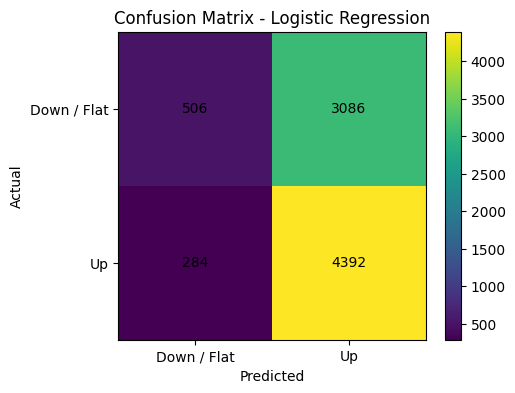

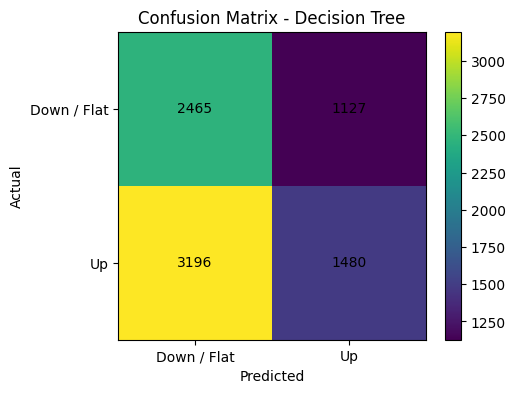

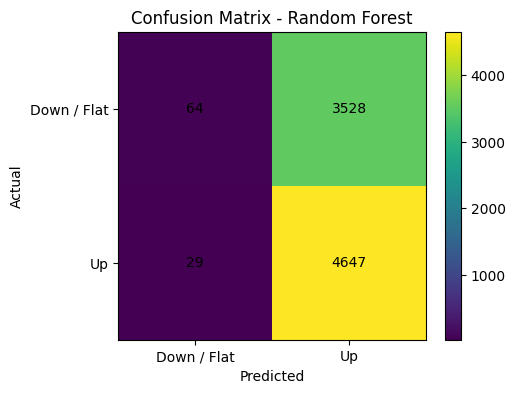

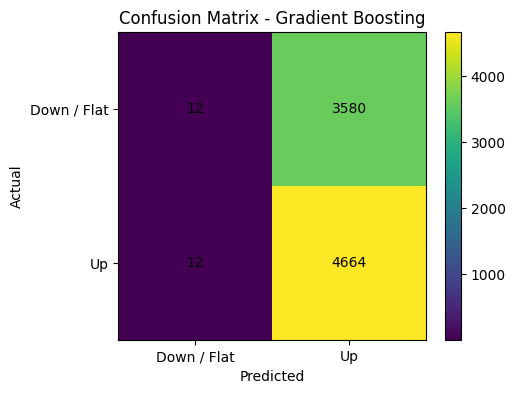

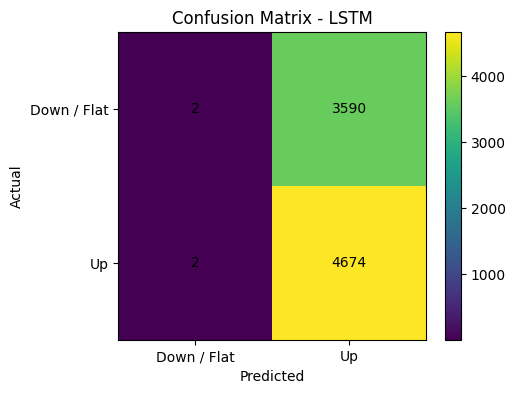

In [26]:
def plot_confusion(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Down / Flat", "Up"])
    plt.yticks([0, 1], ["Down / Flat", "Up"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()

plot_confusion("Logistic Regression", y_test, log_pred)
plot_confusion("Decision Tree", y_test, dt_pred)
plot_confusion("Random Forest", y_test, rf_pred)
plot_confusion("Gradient Boosting", y_test, gb_pred)
plot_confusion("LSTM", y_test_seq, lstm_pred)

## 22. Prediction confidence distribution

This checks whether the model is confident or just stuck around 0.50.

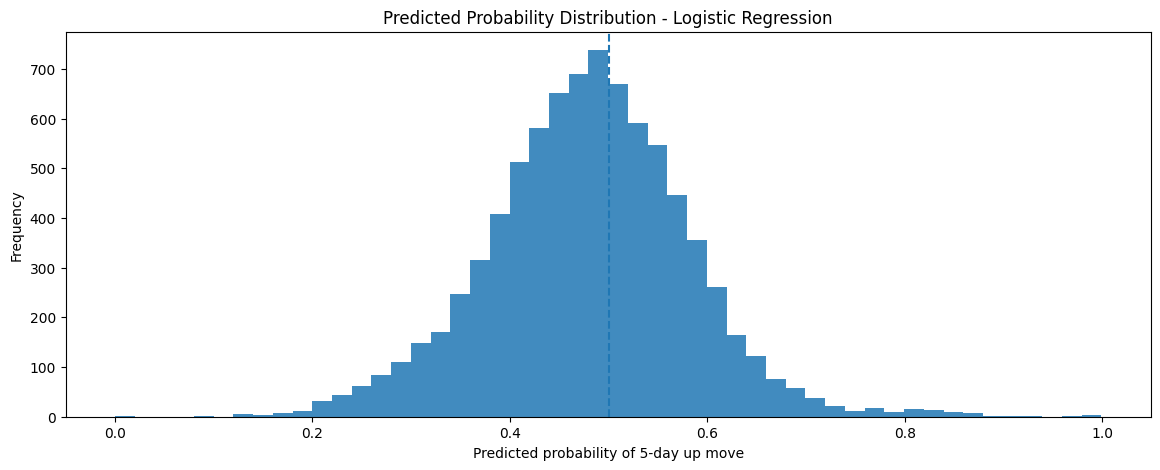

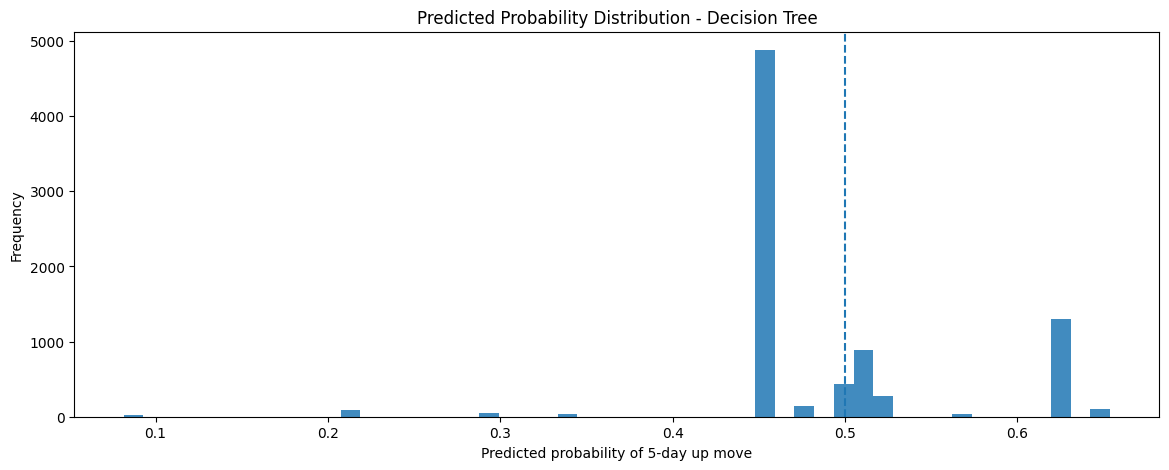

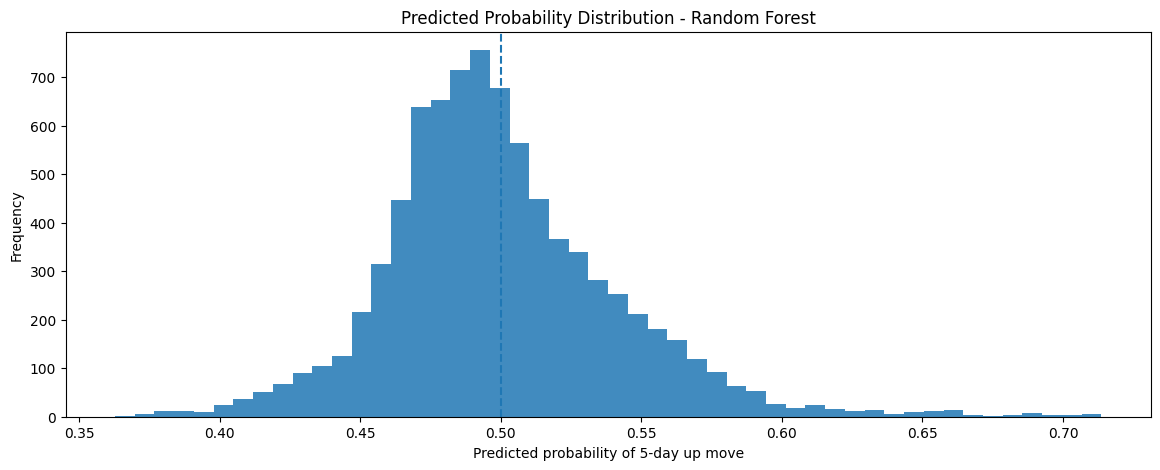

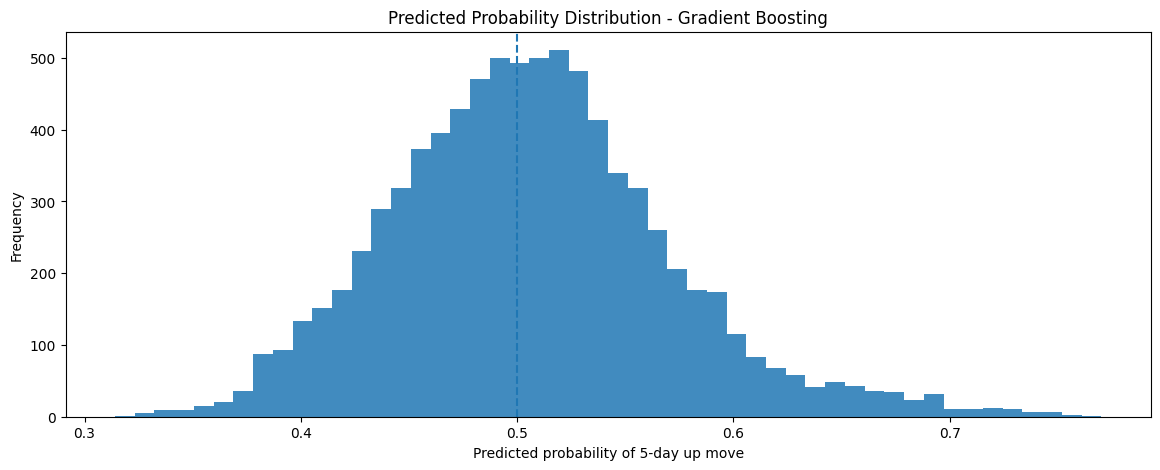

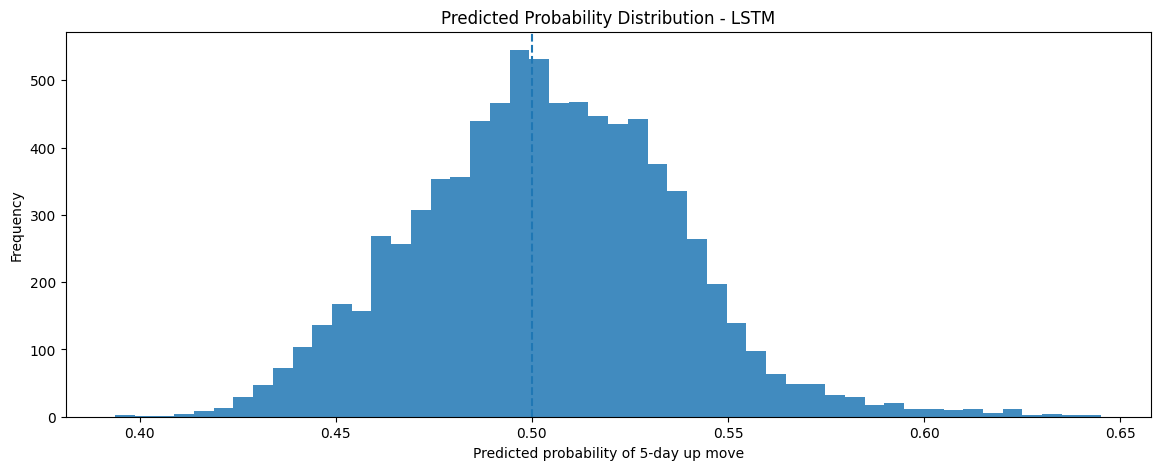

In [27]:
def plot_probability_distribution(name, y_prob):
    plt.figure(figsize=(14, 5))
    plt.hist(y_prob, bins=50, alpha=0.85)
    plt.axvline(0.50, linestyle="--")
    plt.title(f"Predicted Probability Distribution - {name}")
    plt.xlabel("Predicted probability of 5-day up move")
    plt.ylabel("Frequency")
    plt.show()

plot_probability_distribution("Logistic Regression", log_prob)
plot_probability_distribution("Decision Tree", dt_prob)
plot_probability_distribution("Random Forest", rf_prob)
plot_probability_distribution("Gradient Boosting", gb_prob)
plot_probability_distribution("LSTM", lstm_prob)

## 23. Feature importance

Random Forest gives a simple importance view.

This should be treated as a guide, not absolute truth.

,Feature,Importance
67,MKT_IWM_Vol_10,0.038401
55,MKT_SPY_Vol_10,0.030393
83,MKT_USO_Vol_10,0.029946
59,MKT_QQQ_Vol_10,0.026851
91,MKT_UVXY_Vol_10,0.021857
31,MACD_Signal,0.021470
43,MKT_SLV_Vol_10,0.020665
21,Volatility_60,0.020523
39,MKT_GLD_Vol_10,0.019848
20,Volatility_30,0.019480


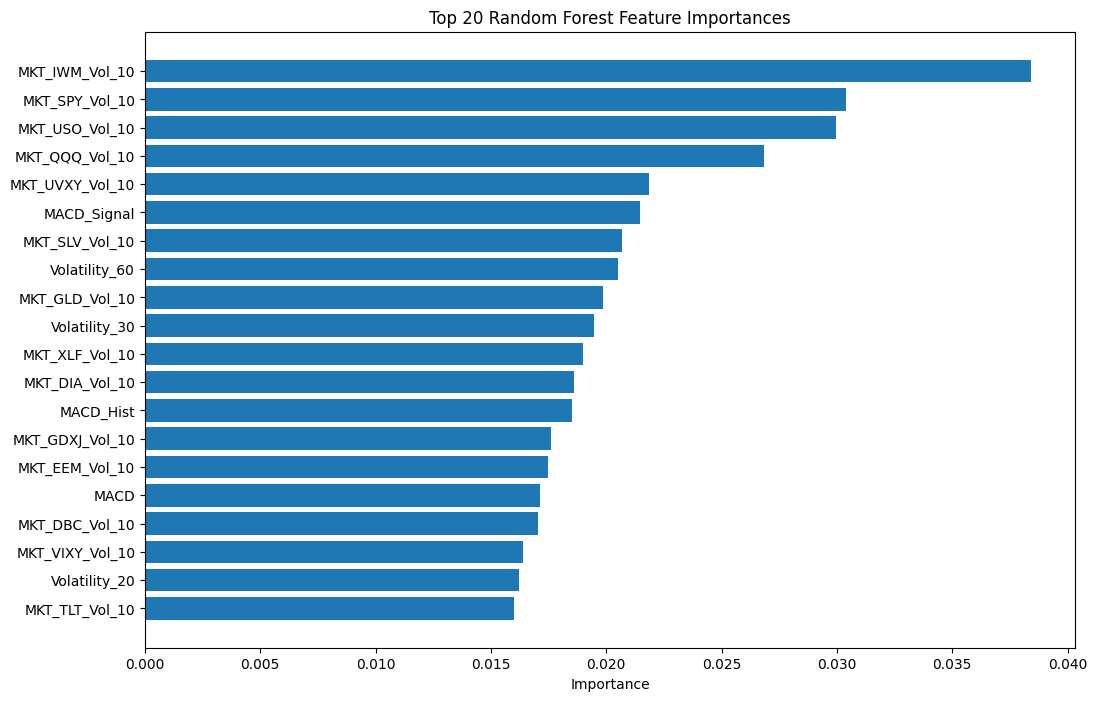

In [28]:
importance_df = pd.DataFrame({
    "Feature": X_train_val.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(25))

plt.figure(figsize=(12, 8))
plt.barh(importance_df.head(20)["Feature"][::-1], importance_df.head(20)["Importance"][::-1])
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

## 24. LSTM training curves

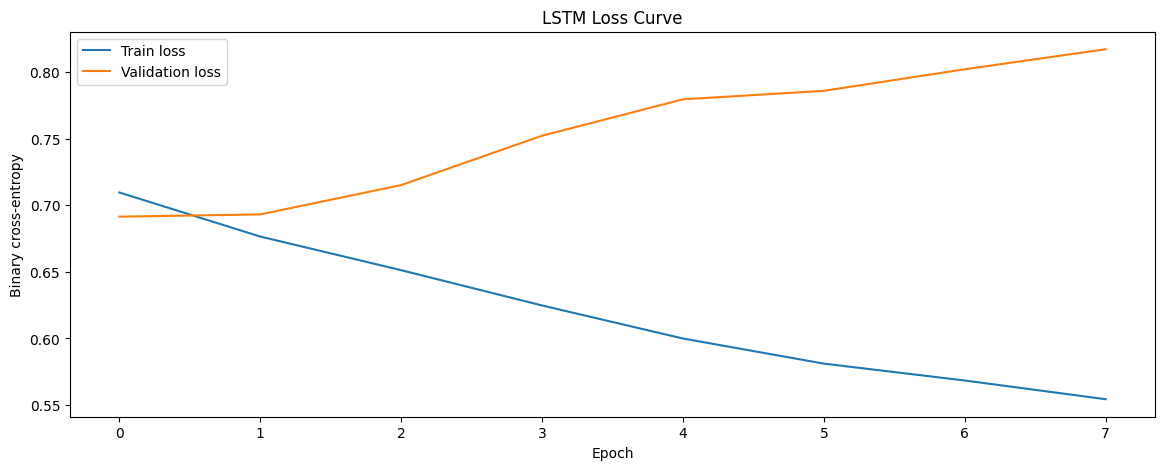

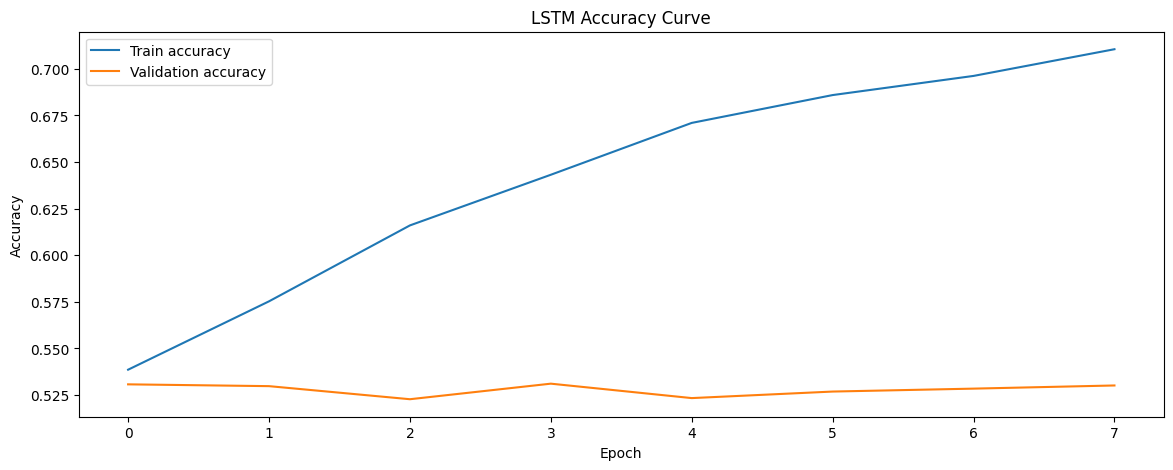

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("LSTM Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 25. Final analysis notes

Use these points after the notebook runs.

- The target was changed from next-day direction to 5-day direction because one-day movement was too noisy.
- The dataset is still fully used. No GLD-only filtering is applied.
- Every rolling feature and target is built inside each ticker.
- The split is time-based. No random shuffle is used.
- The models are compared against a majority-class baseline.
- Random Forest and Gradient Boosting are selected using validation results, not hard-coded after test results.
- Thresholds are selected on the validation set only.
- If the results improve, say the longer target horizon gave the model a clearer signal.
- If the results are still weak, say the market signal remains limited, which is normal for short-horizon financial forecasting.

In [30]:
best_model = comparison_df.iloc[0]

print("Best model by F1:", best_model["Model"])
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"F1 Score: {best_model['F1']:.4f}")
print(f"ROC-AUC : {best_model['ROC_AUC']:.4f}")
print(f"Threshold: {best_model['Threshold']}")
print()
print("Plain-English conclusion:")
print("The final task was framed as a 5-day direction classification problem instead of exact return regression or next-day direction.")
print("This is a more stable target because one-day financial movement is often too noisy for reliable modelling.")
print("The full multi-asset dataset was used, but features and targets were built per ticker to avoid leakage between assets.")

Best model by F1: Random Forest
Accuracy: 0.5698
F1 Score: 0.7232
ROC-AUC : 0.5137
Threshold: 0.41000000000000003

Plain-English conclusion:
The final task was framed as a 5-day direction classification problem instead of exact return regression or next-day direction.
This is a more stable target because one-day financial movement is often too noisy for reliable modelling.
The full multi-asset dataset was used, but features and targets were built per ticker to avoid leakage between assets.
